In [74]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import chi2, uniform

# Exercise 1


## 1 

In [61]:
def linear_conguence_operator(a,c,M,x):
    xi =(a*x+c) % M
    random_number = xi/M
    return random_number,xi

In [62]:
def linear_congruence_RNG(a,c,M,x,n): 
    numbers = []
    for i in range(n): 
        random_number, x = linear_conguence_operator(a,c,M,x)
        numbers.append(random_number)
    return numbers

In [63]:
def chi_square_test(n_observed, n_expected,m):
    n = len(n_observed)
    df = n-1-m
    T = np.sum(((n_observed-n_expected)**2)/n_expected)
    return chi2.sf(T,df)


### a)

(array([1250.,  625., 1250.,  625., 1250.,  625., 1250.,  625., 1250.,
        1250.]),
 array([0.     , 0.09375, 0.1875 , 0.28125, 0.375  , 0.46875, 0.5625 ,
        0.65625, 0.75   , 0.84375, 0.9375 ]),
 <BarContainer object of 10 artists>)

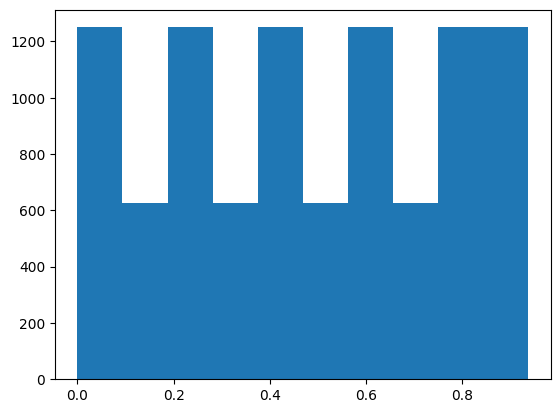

In [64]:
# Generating random numbers (10000) and histogram
num = linear_congruence_RNG(5,1,16,3,10000)
plt.hist(num,10)

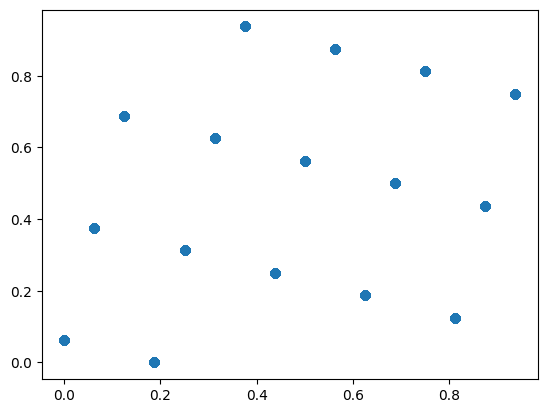

In [65]:
plt.scatter(num[:-1],num[1:])

In [ ]:
# chi squared
bins = 10
observed, _ = np.histogram(num, bins=bins)
expected = np.ones(bins) * (10000 / bins)
chi_square_test(observed,expected, 0)

5.132863848608182e-196

In [79]:
# Kologmigigi
def empirical_cdf(x,num): 
    num = np.array(num)
    return np.sum(num <= x)/len(num)

def Kolmogorov_smirnov(num, n):
    x = np.linspace(0,1,n) # n controls how close we are to treating it like a continous function
    val = []
    for i in x:
        val.append(abs(uniform.cdf(i)-empirical_cdf(i,num)))

    return np.max( val)


In [80]:
Kolmogorov_smirnov(num, 100)

0.0625